Simulating p = 0.4 ...
Simulating p = 0.5 ...
Simulating p = 0.6 ...


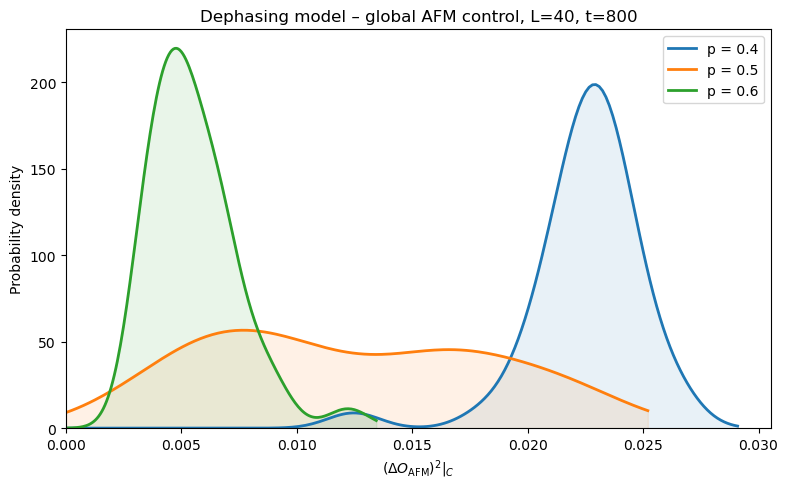

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------- Parameters -------------------
L = 40                       # system size (even)
p_vals = [0.4, 0.5, 0.6]     # control probabilities to compare
num_circuits = 40
num_shots   = 1000
t_max = L**2//2              # generous steady‑state time
rng = np.random.default_rng(12345)

# Precomputed constants for the global adder A
shifts = np.arange(L-1, -1, -1, dtype=np.uint64)
weights = (1 << shifts).astype(np.uint64)
N = np.uint64(1) << np.uint64(L)
offset_1_6 = np.uint64(N // 6)      # exact truncation of 1/6
offset_1_3 = np.uint64(N // 3)      # exact truncation of 1/3
threshold_1_4 = N // np.uint64(4)

# ------------------- Circuit generation (unchanged walk) -------------------
def generate_circuit():
    circuit = []
    pos = 1
    for _ in range(t_max):
        if pos == 1:
            op, next_pos = 'B', 2
        elif pos == L:
            op, next_pos = 'C', L - 1
        else:
            if rng.random() < p:
                op, next_pos = 'C', pos - 1
            else:
                op, next_pos = 'B', pos + 1

        if op == 'B':
            T = rng.dirichlet([1.0, 1.0, 1.0, 1.0], size=4).T
            circuit.append(('B', pos-1, T))
        else:
            circuit.append(('C', pos-1, None))
        pos = next_pos
    return circuit

# ------------------- Global adder (unchanged) -------------------
def apply_global_adder_bits(bits):
    n = bits.dot(weights).astype(np.uint64)
    mask = n < threshold_1_4
    n_new = n + offset_1_6 * mask + offset_1_3 * (~mask)
    n_new %= N
    bits[:, :] = ((n_new[:, None] >> shifts) & 1).astype(np.int8)
    return bits

# ------------------- Simulate one circuit (FIXED scrambler) -------------------
def simulate_circuit(circuit):
    bits = np.zeros((num_shots, L), dtype=np.int8)

    for op, i, T in circuit:
        if op == 'C':
            # Global AFM control: A T^{-1} R_L
            bits[:, -1] = 0                     # reset last qubit
            bits = np.roll(bits, 1, axis=1)      # right cyclic shift (T^{-1})
            bits = apply_global_adder_bits(bits)  # adder A
        else:
            # Scrambler B = U T:  left cyclic shift T, then U on last two qubits
            bits = np.roll(bits, -1, axis=1)     # left shift T
            # Two‑qubit gate on the (now) last two qubits: indices L-2 and L-1
            s = (bits[:, L-2].astype(np.int8) << 1) | bits[:, L-1].astype(np.int8)
            for s_val in range(4):
                mask = (s == s_val)
                if mask.sum() == 0: continue
                probs = T[:, s_val]
                s_new = rng.choice(4, size=mask.sum(), p=probs)
                bits[mask, L-2] = (s_new >> 1).astype(np.int8)
                bits[mask, L-1] = (s_new & 1).astype(np.int8)
            # Note: the position i from the circuit is no longer used because
            # the shift always brings the active pair to the right end.
            # We keep the original circuit list for consistency.

    # Néel order parameter O_AFM per shot
    Z = 1 - 2 * bits.astype(np.float64)
    Z_shift = np.roll(Z, -1, axis=1)
    O_AFM = -np.mean(Z * Z_shift, axis=1)
    return float(np.var(O_AFM, ddof=1))

# ------------------- Main simulation -------------------
variances_all = {}
for p in p_vals:
    print(f"Simulating p = {p} ...")
    variances = np.empty(num_circuits, dtype=float)
    for c in range(num_circuits):
        circ = generate_circuit()
        variances[c] = simulate_circuit(circ)
    variances_all[p] = variances

# ------------------- Overlaid KDE plot -------------------
plt.figure(figsize=(8,5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for p, col in zip(p_vals, colors):
    var = variances_all[p]
    kde = gaussian_kde(var)
    x = np.linspace(0, var.max() * 1.1, 200)
    plt.plot(x, kde(x), color=col, lw=2, label=f'p = {p}')
    plt.fill_between(x, kde(x), alpha=0.1, color=col)
plt.xlabel(r'$(\Delta O_{\mathrm{AFM}})^2|_C$')
plt.ylabel('Probability density')
plt.title(f'Dephasing model – global AFM control, L={L}, t={t_max}')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()